# Analyse exploratoire (EDA) : Telco Customer Churn

## Objectif
Comprendre la distribution du churn, identifier les variables les plus liées à la résiliation, vérifier statistiquement ces relations (pas seulement visuellement), et dégager les segments de clients à risque en vue de la modélisation.

## Étapes
1. Chargement du dataset nettoyé
2. Taux de churn global (déséquilibre des classes)
3. Variables numériques vs churn (distributions + test de Mann-Whitney)
4. Variables catégorielles vs churn (proportions + test du Chi²)
5. Corrélations entre variables numériques (multicolinéarité)
6. Segments de clients à risque (croisements de plusieurs variables)
7. Synthèse des facteurs de risque retenus pour la modélisation

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/processed/telco_cleaned.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# taux de churn global
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print('\n',churn_pct.round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


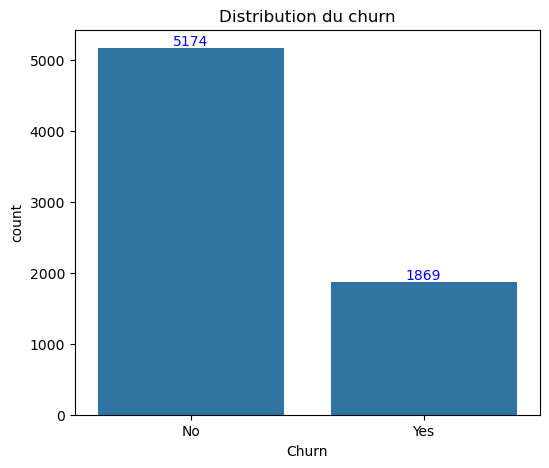

In [8]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='Churn')
for container in ax.containers:
    ax.bar_label(container, color='blue')
plt.title('Distribution du churn')
plt.show()

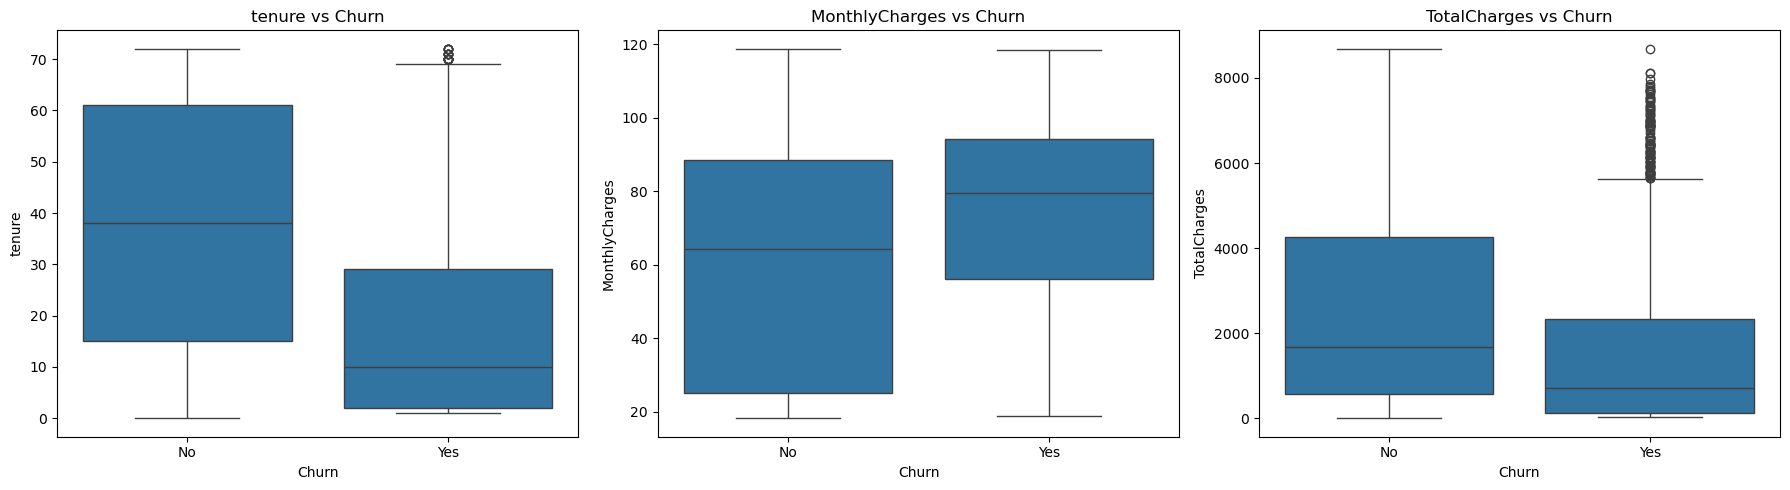

In [9]:
# variables numériques vs churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

In [10]:
for col in numeric_cols:
    group_no = df[df['Churn'] == 'No'][col]
    group_yes = df[df['Churn'] == 'Yes'][col]
    stat, p_value = stats.mannwhitneyu(group_no, group_yes)
    print(f'{col} : p-value = {p_value:.6f}')

tenure : p-value = 0.000000
MonthlyCharges : p-value = 0.000000
TotalCharges : p-value = 0.000000


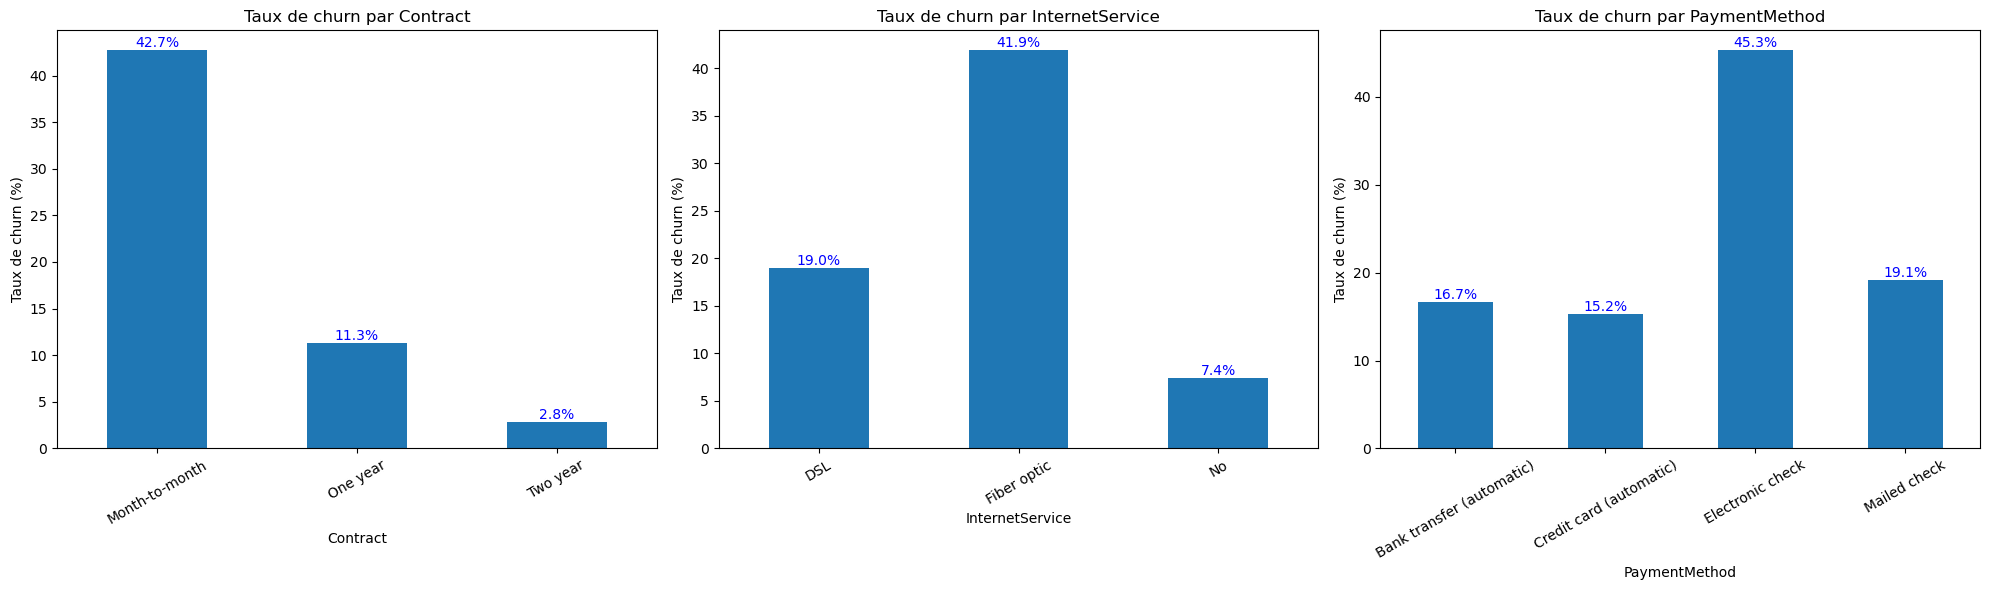

In [16]:
# variables catégorielles vs churn
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Taux de churn par {col}')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=30)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', color='blue')

plt.tight_layout()
plt.show()

In [22]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    print('\n',contingency_table)
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'{col}: chi2 = {chi2:.2f}, p-value = {p_value:.6f}')


 Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
Contract: chi2 = 1184.60, p-value = 0.000000

 Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
InternetService: chi2 = 732.31, p-value = 0.000000

 Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308
PaymentMethod: chi2 = 648.14, p-value = 0.000000


In [23]:
# corrélations entre variables numériques (multicolinéarité)
corr_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print(corr_matrix)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


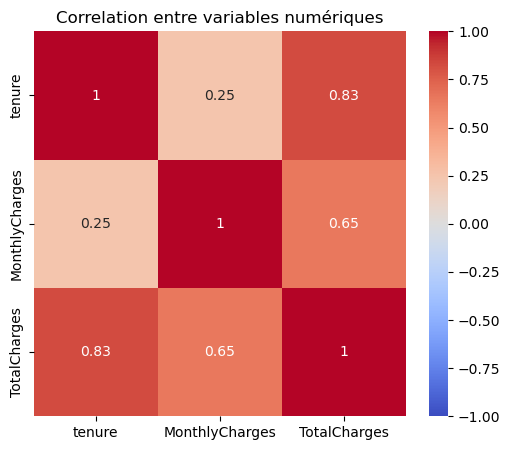

In [24]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation entre variables numériques')
plt.show()

In [25]:
# segments de clients à risque
segment_risk = df.groupby(['Contract', 'InternetService'])['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
segment_risk = segment_risk.sort_values(ascending=False)
print(segment_risk)

Contract        InternetService
Month-to-month  Fiber optic        54.6
                DSL                32.2
One year        Fiber optic        19.3
Month-to-month  No                 18.9
One year        DSL                 9.3
Two year        Fiber optic         7.2
One year        No                  2.5
Two year        DSL                 1.9
                No                  0.8
Name: Churn, dtype: float64


## Synthèse de l'EDA

### Taux de churn global
26.54% (déséquilibre modéré, à prendre en compte dans le choix des métriques d'évaluation)

### Variables numériques significatives (test de Mann-Whitney, p < 0.001)
- tenure : les clients qui résilient ont une ancienneté bien plus faible (médiane 10 mois vs 38 mois)
- MonthlyCharges : les clients qui résilient paient plus cher (médiane 79 dollars vs 64 dollars)
- TotalCharges : fortement corrélée à tenure (0.83) et MonthlyCharges (0.65), candidate à la suppression pour multicolinéarité

### Variables catégorielles significatives (test du Chi², p < 0.001)
- Contract : facteur le plus déterminant (chi2 = 1184.60) - Month-to-month (42.7%) vs Two year (2.8%)
- InternetService : Fiber optic (41.9%) vs No internet (7.4%)
- PaymentMethod : Electronic check (45.3%) vs autres méthodes (15-19%)

### Segment le plus à risque
Month-to-month + Fiber optic : 54.6% de churn (effet d'interaction, plus fort que la somme des effets individuels)

### Points de vigilance pour la modélisation
- Retirer TotalCharges (multicolinéarité avec tenure et MonthlyCharges)
- Envisager une variable d'interaction Contract x InternetService
- Déséquilibre des classes (73/27) à gérer avec les bonnes métriques (précision, rappel, F1, pas seulement l'exactitude)